### Simple Linear Regression Problem

. Salary Dataset

In [87]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score


In [88]:
df = pd.read_csv('Datasets/Salary_dataset.csv')
df.drop(columns=['Unnamed: 0'], inplace=True)
df.head()

,YearsExperience,Salary
0,1.2,39344.0
1,1.4,46206.0
2,1.6,37732.0
3,2.1,43526.0
4,2.3,39892.0


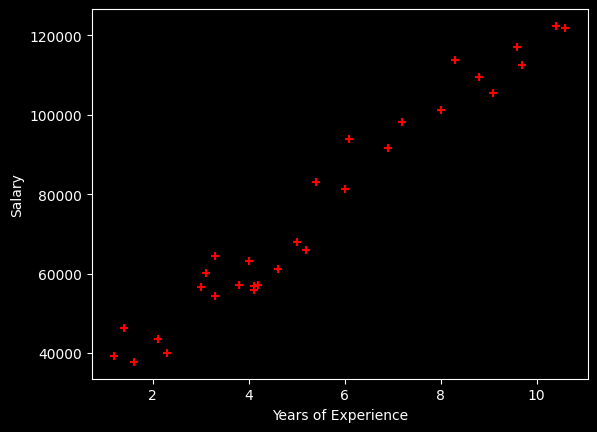

In [89]:
# EDA
%matplotlib inline
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.scatter(df['YearsExperience'],df['Salary'], color='red', marker='+')
plt.show()

- Create a class object from linear regression and fit the 2 df columns plotted

In [90]:
X = df[['YearsExperience']] # independent variable
y = df['Salary'] # dependent variable

In [91]:
# train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [92]:
model = LinearRegression()  # create a linear regression model object

In [93]:
# Cross Validation
cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='r2')

print(f"Cross-Validation R² Scores: {cv_scores}")
print("Mean R²:      ", cv_scores.mean())
print("Std R²:       ", cv_scores.std())   # low std = stable model

Cross-Validation R² Scores: [0.98344071 0.86447346 0.96229145 0.99423957 0.68131575]
Mean R²:       0.8971521848581107
Std R²:        0.11727579385675264


In [94]:
# Fit the model to the training data
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


- Predicting

In [95]:
y_pred = model.predict(X_test)  # predict the salary for the test set

- Performance of model (R² - coefficient of determination), MAE, MSE

In [96]:
r2  = r2_score(y_test, y_pred) # r2 means coefficient of determination
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print(f"R² Score: {r2}")
print(f"MAE:      {mae}")
print(f"MSE:      {mse}")


R² Score: 0.9024461774180498
MAE:      6286.453830757745
MSE:      49830096.855908334


In [97]:
# cost function ( MSE / 2)
def cost_function(y_test, y_pred):
    n = len(y_test)
    return (1 / (2 * n)) * np.sum((y_pred - y_test) ** 2)

print(f"Cost Function: {cost_function(y_test, y_pred)}")
print(f"MSE / 2:       {mse / 2}")
print("Both matches, so the model is good enough!")


Cost Function: 24915048.427954167
MSE / 2:       24915048.427954167
Both matches, so the model is good enough!


In [82]:
# RMSE - Root Mean Squared Error
rmse = np.sqrt(mse)
print(f"RMSE: {rmse}")

RMSE: 7059.043621901506


In [83]:
# residuals
residuals = y_test - y_pred
print(residuals)

27    -3155.210113
15    -3560.278095
23    11215.131339
17     7820.195776
8      8967.207955
9     -3000.699707
Name: Salary, dtype: float64


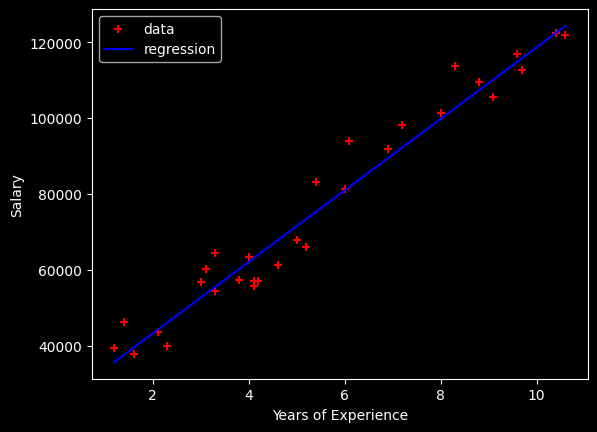

In [84]:
# plot regression line
X_sorted = X.sort_values(by='YearsExperience')
y_pred_sorted = model.predict(X_sorted)

plt.scatter(X, y, color='red', marker='+', label='data')
plt.plot(X_sorted, y_pred_sorted, color='blue', label='regression')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.legend()
plt.show()

In [85]:
# predict salary for 9 years of experience
experience = np.array([[9]])
predicted_salary = model.predict(experience)
print(f"Predicted Salary for 9 years of experience: ${predicted_salary[0]:.2f}")

Predicted Salary for 9 years of experience: $109194.54


C:\Users\rafae\PycharmProjects\Machine-Learning\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [98]:
# mean absolute percentage error (MAPE)
def mean_absolute_percentage_error(y_test, y_pred):
    return np.mean(np.abs((y_test - y_pred) / y_test)) * 100

mape = mean_absolute_percentage_error(y_test, y_pred)
print(f"MAPE: {mape:.2f}%")

MAPE: 7.74%
